# The rule space and its symmetries

At resolution $R$ there are $2^R$ possible born sets and $2^R$ survive sets:
$4^R$ rules in total — over a quarter million at $R=9$. Fortunately the space has
an exact symmetry that halves it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from llna.analysis import boolean_sens, hamming_weight
from llna.rules import (
    binary_indices,
    eca_to_llna,
    get_nonequiv_rules,
    load_nonequiv_rules,
    return_equivalent_rule,
    return_life_like_dict,
)

## Black-white equivalence

Swap the roles of dead and alive everywhere and a rule $(B, S)$ behaves exactly
like the rule $(\mathrm{comp}(\mathrm{rev}(S)), \mathrm{comp}(\mathrm{rev}(B)))$:
mirror each interval set (the density complement reverses interval indices under
the `iso` encoding), take the set complement, and swap $B$ with $S$. The map is an
involution, so rules pair up; keeping the lexicographic minimum of each pair
leaves

$$K(R) = \frac{4^R + 2^R}{2}$$

non-equivalent rules (the $2^R$ term counts the self-equivalent ones).

In [2]:
for resolution in range(2, 10):
    rules = get_nonequiv_rules(resolution)
    expected = (4**resolution + 2**resolution) // 2
    print(f"R={resolution}: {len(rules):>7} non-equivalent rules (formula: {expected:>7})")

R=2:      10 non-equivalent rules (formula:      10)
R=3:      36 non-equivalent rules (formula:      36)
R=4:     136 non-equivalent rules (formula:     136)
R=5:     528 non-equivalent rules (formula:     528)
R=6:    2080 non-equivalent rules (formula:    2080)
R=7:    8256 non-equivalent rules (formula:    8256)
R=8:   32896 non-equivalent rules (formula:   32896)
R=9:  131328 non-equivalent rules (formula:  131328)


In [3]:
# the equivalence in action: 'life' pairs with a rule from the same family table
life_like = return_life_like_dict()
beta, sigma = life_like["life"]
partner = return_equivalent_rule(9, binary_indices(beta), binary_indices(sigma), return_decimals=True)
print(f"life = (beta={beta}, sigma={sigma})  <->  equivalent rule (beta={partner[0]}, sigma={partner[1]})")
print("anneal:", life_like["anneal"], " <-> ", return_equivalent_rule(
    9, binary_indices(life_like['anneal'][0]), binary_indices(life_like['anneal'][1]), return_decimals=True))

life = (beta=8, sigma=12)  <->  equivalent rule (beta=415, sigma=479)
anneal: (464, 488)  <->  (464, 488)


The enumeration is vectorised (bit-reversal tables); $R=9$ takes tens of
milliseconds. For repeated use, `load_nonequiv_rules` caches the table as `.npy` —
the repository ships the $R=9$ table in `data/rule_tables/`.

In [4]:
import time

t0 = time.perf_counter()
table = load_nonequiv_rules(9, cache_dir="../data/rule_tables")
print(f"{len(table)} rules loaded in {(time.perf_counter() - t0) * 1000:.1f} ms; first rows:")
print(table[:4])

131328 rules loaded in 1.4 ms; first rows:
[[0 0]
 [0 1]
 [0 2]
 [0 3]]


## Genotype metrics

Two cheap, simulation-free numbers summarise how "active" a rule is for nodes of
a given degree:

- the **Hamming weight** (Langton parameter): the fraction of neighbourhood
  configurations that map to *alive*;
- the **Boolean sensitivity**: how often flipping a single input bit (the node
  itself, or one neighbour) flips the output.

Both weigh neighbourhood sums binomially. Plotted against each other over all 528
non-equivalent $R=5$ rules, they trace the classic arch: rules with intermediate
Hamming weight can be the most sensitive.

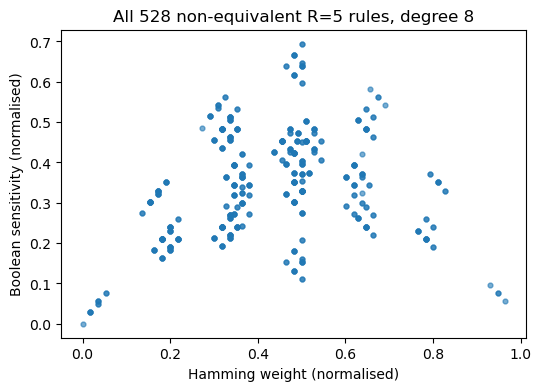

In [5]:
rules5 = get_nonequiv_rules(5)
degree = 8
hw = np.array([hamming_weight(5, binary_indices(b), binary_indices(s), degree) for b, s in rules5])
bs = np.array([boolean_sens(5, binary_indices(b), binary_indices(s), degree, norm_degree=True) for b, s in rules5])

plt.figure(figsize=(6, 4))
plt.scatter(hw, bs, s=12, alpha=0.6)
plt.xlabel("Hamming weight (normalised)")
plt.ylabel("Boolean sensitivity (normalised)")
plt.title(f"All {len(rules5)} non-equivalent R=5 rules, degree {degree}");

## Elementary cellular automata as LLNAs

64 of the 256 ECAs depend on their inputs only through the centre state and the
neighbour density — those translate directly. The parity rule 150 becomes
$R=3$, $B=\{1\}$ (born on exactly one alive neighbour), $S=\{0, 2\}$
(survive on zero or two): XOR in density language. Notebook 03 uses this to
benchmark Lyapunov spectra against a closed form.

In [6]:
b_set, s_set = eca_to_llna(150)
print(f"ECA 150 -> B={b_set}, S={s_set}")

ECA 150 -> B=[1], S=[0, 2]
